***Módulos a Importar***

In [55]:
import sympy as sp
from sympy.physics.mechanics import dynamicsymbols, ReferenceFrame
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import fsolve

# PARTE 1 - MODELOS

# Punto 1

0. Funciones a Utilizar

In [56]:
# Sabiendo theta1 y theta2, calcula la posicion x y y del punto 1 (Direct Kinematics)

def lista_posiciones(lista_theta1, lista_theta2):

  lista_posx_p1 = []
  lista_posy_p1 = []

  for elemento_unico in range(len(lista_theta1)):
    theta1_unico = lista_theta1[elemento_unico]
    theta2_unico = lista_theta2[elemento_unico]
    lista_posx_p1.append(f_posicionx_p1(theta1_unico, theta2_unico))
    lista_posy_p1.append(f_posiciony_p1(theta1_unico, theta2_unico))

  return lista_posx_p1, lista_posy_p1

In [57]:
# Sabiendo las coordenadas X y Y de los 3 puntos de interés, graficar su movimiento en el espacio

def graficar_puntos(x1, y1, x2, y2, x3, y3):
    plt.figure(figsize=(8, 8))

    plt.plot(x1, y1, label="Punto 1", color='maroon')
    plt.plot(x2, y2, label="Punto 2", color = 'forestgreen')
    plt.plot(x3, y3, label="Punto 3", color = 'steelblue')

    plt.xlabel("x")
    plt.ylabel("y")
    plt.title("Trayectoria de los 3 puntos")
    plt.axis("equal")
    plt.grid(True)
    plt.legend()

    plt.show()

In [58]:
# Sabiendo las coordenadas X y Y de los 3 puntos de interés, graficar su variación de acuerdo al movimiento del actuador lineal s

def graficar_posiciones_actuador(x1, y1, x2, y2, x3, y3, s):

    # Punto 1
    plt.figure(figsize=(10, 6))
    plt.plot(s, x1, label='P1 - x', color='firebrick')
    plt.plot(s, y1, label='P1 - y', color = 'teal')
    plt.xlabel('Desplazamiento del actuador [mm]')
    plt.ylabel('Posición [mm]')
    plt.title('Posición del punto P1 vs desplazamiento')
    plt.grid()
    plt.legend()
    plt.show()

    # Punto 2
    plt.figure(figsize=(10, 6))
    plt.plot(s, x2, label='P2 - x', color='firebrick')
    plt.plot(s, y2, label='P2 - y', color = 'teal')
    plt.xlabel('Desplazamiento del actuador [mm]')
    plt.ylabel('Posición [mm]')
    plt.title('Posición del punto P2 vs desplazamiento')
    plt.grid()
    plt.legend()
    plt.show()

    # Punto 3
    plt.figure(figsize=(10, 6))
    plt.plot(s, x3, label='P3 - x', color='firebrick')
    plt.plot(s, y3, label='P3 - y', color = 'teal')
    plt.xlabel('Desplazamiento del actuador [mm]')
    plt.ylabel('Posición [mm]')
    plt.title('Posición del punto P3 vs desplazamiento')
    plt.grid()
    plt.legend()
    plt.show()


In [59]:
# Sabiendo las coordenadas X y Y de los 3 puntos de interés, calcular sus respectivos ángulos con respecto al Eje Vertical

def angulo_respecto_a_eje(posicionesx, posicionesy):
    angulos = []
    for elemento in range(len(posicionesx)):
        componentex = posicionesx[elemento]
        componentey = posicionesy[elemento]
        angulo_unico = np.arctan(componentex/componentey)
        angulo_unico = np.rad2deg(angulo_unico)
        angulos.append(angulo_unico)
    return angulos

In [60]:
# Sabiendo los ángulos de cada punto con respecto al Eje Vertical, graficar su variación de acuerdo al movimiento del actuador lineal s

def graficar_angulos_actuador(angulos1, angulos2, angulos3, s):

    plt.figure(figsize=(10, 6))
    plt.plot(s, angulos1, label='Angulo P1 - x', color = 'dodgerblue' )
    plt.plot(s, angulos2, label='Angulo P2 - x', color = 'rebeccapurple' )
    plt.plot(s, angulos3, label='Angulo P3 - x', color = 'darkorange' )
    plt.xlabel('Desplazamiento del actuador [mm]')
    plt.ylabel('Ángulo [deg]')
    plt.title('Ángulos de los Puntos respecto al Eje X')
    plt.grid()
    plt.legend()
    plt.show()

1. Definición del Modelo

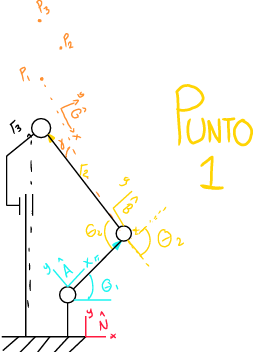

In [61]:
# 1. Definición de Variables
theta, theta2 = dynamicsymbols('theta theta2')
l1, l2, l3_min, s, px, py = sp.symbols('l1 l2 l3_min s px py')

# s == Que tanto se esta expandiendo desde su punto de compresión maximo (entre 0 / completamente comprimido y 20 / completamente estirado)

# 2. Definición de Marcos
N = ReferenceFrame('N')
A = N.orientnew('A', 'Axis', (theta, N.z))
B = A.orientnew('B', 'Axis', (-theta2, A.z))

# 3. Definición de Medidas y Vectores
l3 = l3_min + s
offset = px*N.x + py*N.y
r1 = l1*A.x
r2 = -l2*B.x
r3 = l3*N.y + offset

# 4. Definición de Ecuaciones y Loop
loop = r1 + r2 - r3 
eq_x = loop.dot(N.x)
eq_y = loop.dot(N.y)
eq = [eq_x, eq_y]

# 5. Conversión a función numérica
fun_eq = sp.lambdify((theta, theta2, l1, l2, l3_min, s, px, py), eq, "numpy")

# 6. Fijación de Valores
val = {
    l1: 30,
    l2: 30,
    l3_min: 30,
    px: 10,
    py: 5,
}
s_val = np.linspace(0, 20, 100)

# 7. Aproach Numérico (hallar theta1 y theta2)

estimacion_angulos = [np.radians(45), np.radians(90)]
theta1_sol = []
theta2_sol = []

for s_num in s_val:
  regleta = lambda v: fun_eq(*v, val[l1],val[l2], val[l3_min],s_num,val[px],val[py])
  solu=fsolve(regleta,estimacion_angulos)
  theta1_sol.append(solu[0])
  theta2_sol.append(solu[1])
  estimacion_angulos=solu


print(theta1_sol)

[0.3735726061346202, 0.3791689667368741, 0.38476391310247826, 0.3903578716690549, 0.39595126868827213, 0.4015445304606573, 0.4071380835727231, 0.4127323551367031, 0.4183277730332381, 0.42392476615737396, 0.4295237646682475, 0.4351252002428447, 0.4407295063342363, 0.4463371184347184, 0.45194847434429314, 0.4575640144449563, 0.4631841819812776, 0.4688094233477806, 0.47444018838366236, 0.4800769306754141, 0.48572010786794184, 0.4913701819848157, 0.49702761975831405, 0.5026928929699669, 0.5083664788023475, 0.5140488602029071, 0.5197405262606934, 0.5254419725968541, 0.5311537017698817, 0.5368762236966186, 0.5426100560901124, 0.548355724915488, 0.554113764865082, 0.5598847198541708, 0.5656691435387303, 0.571467599856761, 0.5772806635948294, 0.5831089209816044, 0.5889529703103035, 0.59481342259211, 0.60069090224279, 0.6065860478049137, 0.612499512708288, 0.6184319660714152, 0.6243840935470343, 0.6303565982150642, 0.6363502015265491, 0.6423656443025281, 0.6484036877921012, 0.6544651147943463, 

Plus. Gráfica Ángulos

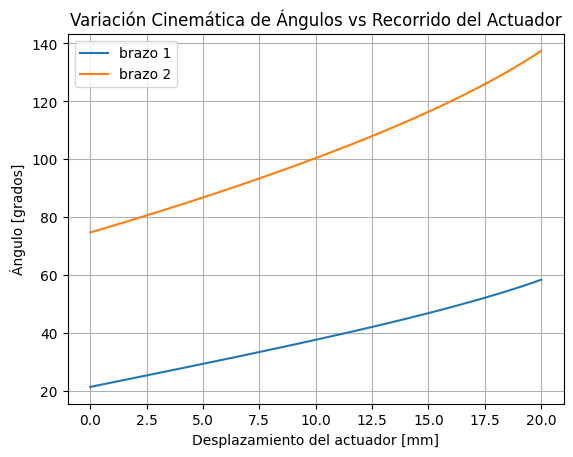

In [62]:
plt.plot(s_val, np.degrees(theta1_sol), label=r'brazo 1')
plt.plot(s_val, np.degrees(theta2_sol), label=r'brazo 2')
plt.xlabel('Desplazamiento del actuador [mm]')
plt.ylabel('Ángulo [grados]')
plt.title('Variación Cinemática de Ángulos vs Recorrido del Actuador')
plt.grid()
plt.legend()
plt.show()

B. Trayectoria en el Espacio de los Puntos

In [63]:
dp1 = sp.symbols('dp1')
gamma1 = sp.symbols('gamma1')
valores_gamma = {gamma1:np.deg2rad(35), dp1:45}

vector_origen_b = offset + r1

G = A.orientnew('G', 'Axis', (-theta2 - gamma1, A.z))

vector_p1 = (vector_origen_b + dp1 *-G.x).express(N).subs(val).subs(valores_gamma)

f_posicionx_p1 = sp.lambdify((theta,theta2),vector_p1.dot(N.x),"numpy")
f_posiciony_p1 = sp.lambdify((theta,theta2),vector_p1.dot(N.y),"numpy")


posicionesx_p1, posicionesy_p1 = lista_posiciones(theta1_sol,theta2_sol)

vp1_p2 = [5,15]
vp1_p3 = [0,30]

posicionesx_p2 = [xi + vp1_p2[0] for xi in posicionesx_p1]
posicionesy_p2 = [yi + vp1_p2[1] for yi in posicionesy_p1]
posicionesx_p3 = [xi + vp1_p3[0] for xi in posicionesx_p1]
posicionesy_p3 = [yi + vp1_p3[1] for yi in posicionesy_p1]

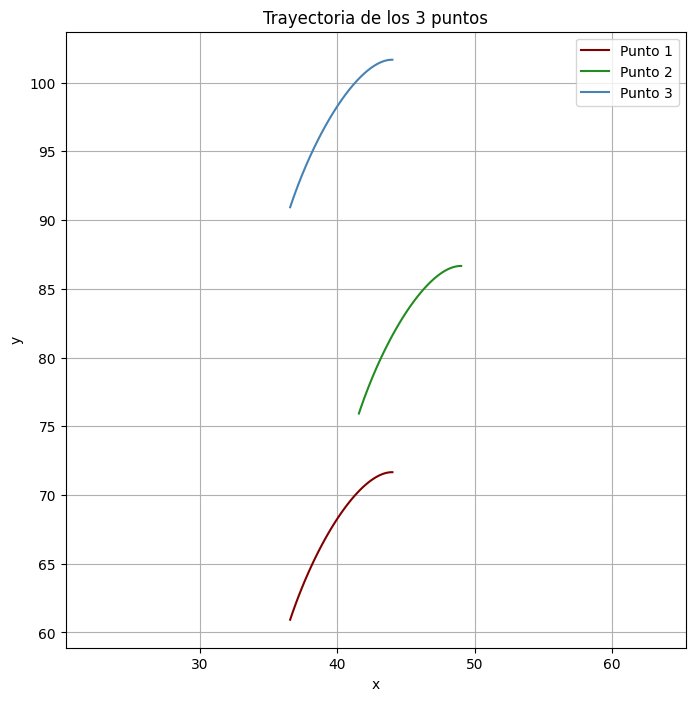

In [64]:
graficar_puntos(posicionesx_p1, posicionesy_p1, posicionesx_p2, posicionesy_p2, posicionesx_p3, posicionesy_p3)

C. Posición en Función del Desplazamiento del Actuador Lineal

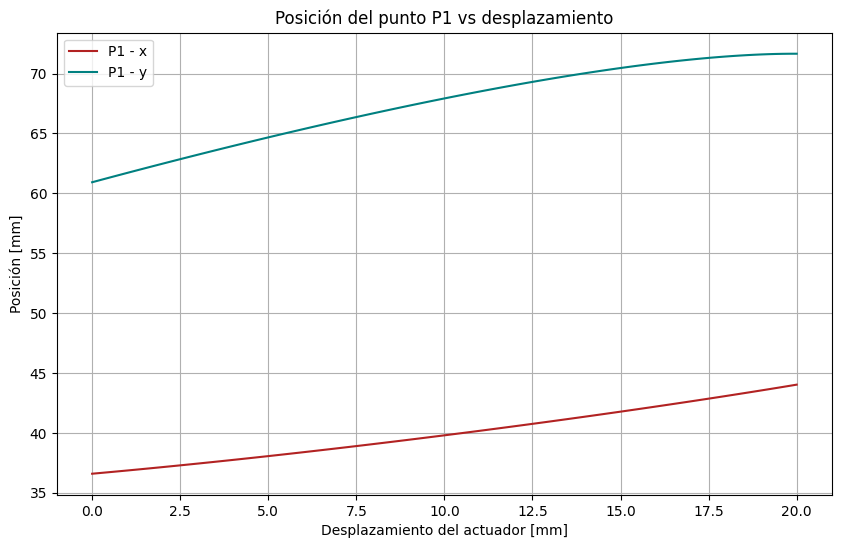

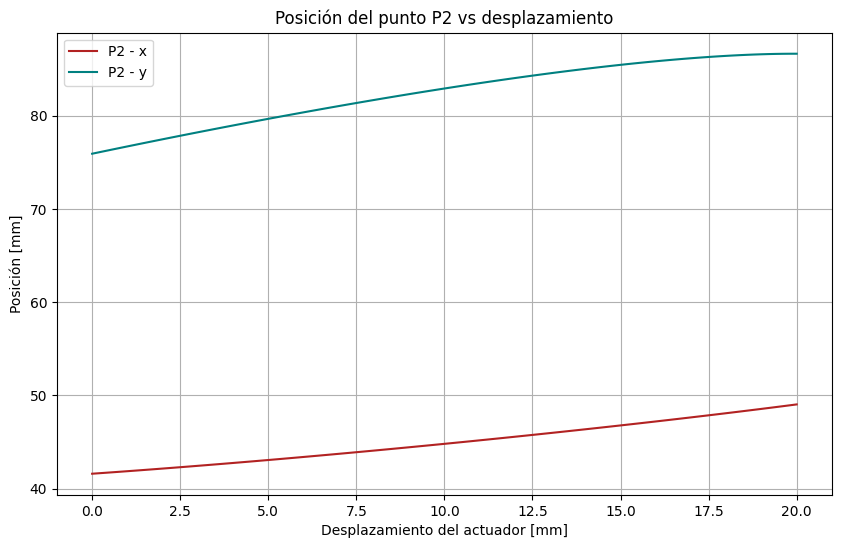

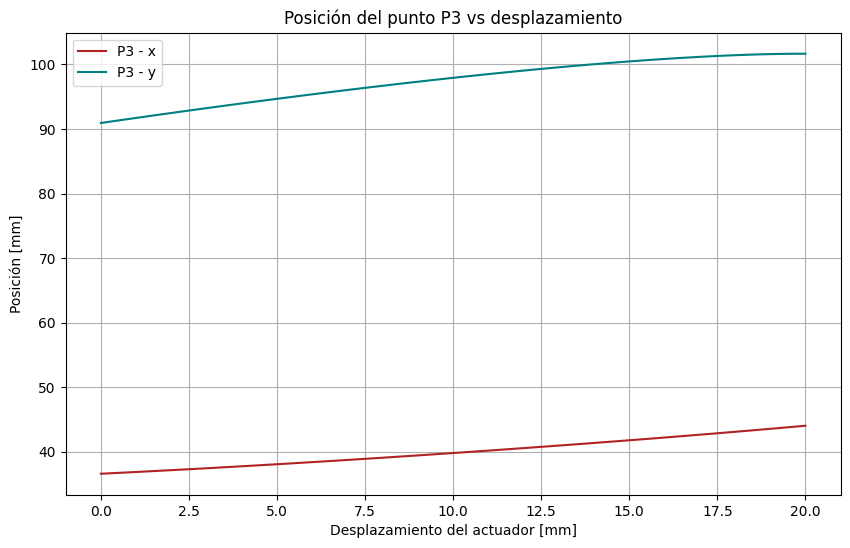

In [65]:
graficar_posiciones_actuador(posicionesx_p1, posicionesy_p1, posicionesx_p2, posicionesy_p2, posicionesx_p3, posicionesy_p3, s_val)

D. Ángulos Respecto al Eje X (En Nuestro Caso Y)

In [66]:
angulos_p1 = angulo_respecto_a_eje(posicionesx_p1, posicionesy_p1)
angulos_p2 = angulo_respecto_a_eje(posicionesx_p2, posicionesy_p2)
angulos_p3 = angulo_respecto_a_eje(posicionesx_p3, posicionesy_p3)

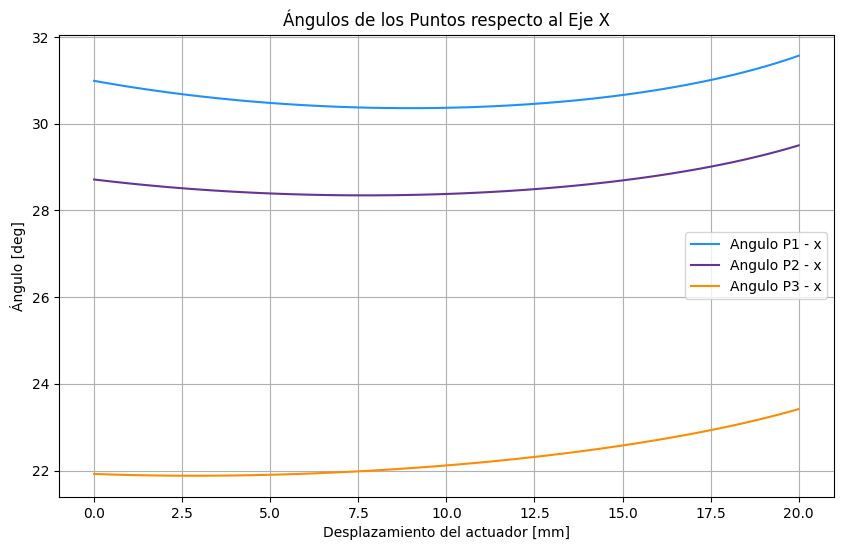

In [67]:
graficar_angulos_actuador(angulos_p1, angulos_p2, angulos_p3, s_val)

E. Datos de Interés para Análisis

In [68]:
# Todos los valores son Respecto al Punto 2 (Promedio)

min_y = min(posicionesy_p2)
max_y = max(posicionesy_p2)
min_x = min(posicionesx_p2)
max_x = max(posicionesx_p2)

print(f" Y Min {min_y}")
print(f" Y Max {max_y}")
print(f" X Min {min_x}")
print(f" X Max {max_x}")

angulo_min_vert = min(angulos_p2)
angulo_max_vert = max(angulos_p2)

print(f" Angulo Min {angulo_min_vert}")
print(f" Angulo Max {angulo_max_vert}")




 Y Min 75.92839395950219
 Y Max 86.65844872329394
 X Min 41.59191992192633
 X Max 49.02852583464669
 Angulo Min 28.346909775602644
 Angulo Max 29.499766878632123


# Punto 2

0. Funciones Nuevas a Utilizar

In [69]:
# Sabiendo theta1 y theta2 Y S, calcula la posicion x y y del punto 1 (Direct Kinematics)

def lista_posiciones_s(lista_theta1, lista_theta2, s_val):

  lista_posx_p1 = []
  lista_posy_p1 = []

  for elemento_unico in range(len(lista_theta1)):
    theta1_unico = lista_theta1[elemento_unico]
    theta2_unico = lista_theta2[elemento_unico]
    s_unico = s_val[elemento_unico]
    lista_posx_p1.append(f_posicionx_p1(theta1_unico, theta2_unico, s_unico))
    lista_posy_p1.append(f_posiciony_p1(theta1_unico, theta2_unico, s_unico))

  return lista_posx_p1, lista_posy_p1

1. Definición del Modelo

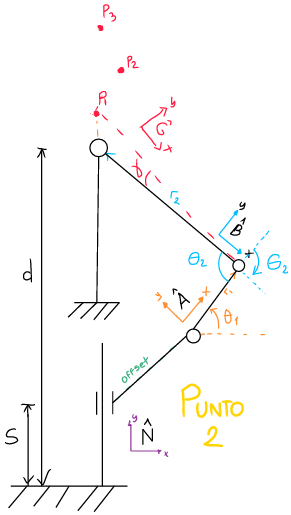

In [70]:
# 1. Definición de Variables
theta, theta2 = dynamicsymbols('theta theta2')
ox, oy, l1,l2, d_fija, s = sp.symbols('ox oy l1 l2 d_fija s')

# 2. Definición de Marcos
N = ReferenceFrame('N')
A= N.orientnew('A', 'Axis', (theta, N.z))
B= A.orientnew('B', 'Axis', (-theta2, N.z))

# 3. Definición de Medidas y Vectores
l3= d_fija
offset= ox*N.x +oy*N.y
subida_piston = s*N.y
r1= l1*A.x
r2= -l2*B.x
r3= l3*N.y 

# 4. Definición de Ecuaciones y Loop
loop= subida_piston + r1+r2-r3 + offset
eqx= loop.dot(N.x)
eqy= loop.dot(N.y)
eq=[eqx, eqy]

# 5. Conversión a Función Numérica
fun_eq=sp.lambdify((theta, theta2,ox,oy,l1,l2,d_fija,s),eq,"numpy")

# 6. Fijación de Valores
val={ox:7, oy:2 ,l1:40, l2:50,d_fija:60}
s_val=np.linspace(0,20,100)

# 7. Approach Numérico (hallar theta1 y theta2)
angulos_estimados=[np.radians(50),np.radians(70)]
theta1_sol=[]
theta2_sol=[]
for s_num  in s_val:
  regleta=lambda v: fun_eq( *v,val[ox],val[oy],val[l1],val[l2],val[d_fija],s_num)
  solu=fsolve(regleta, angulos_estimados)
  theta1_sol.append(solu[0])
  theta2_sol.append(solu[1])
  angulos_estimados= solu


Plus. Gráfica Ángulos

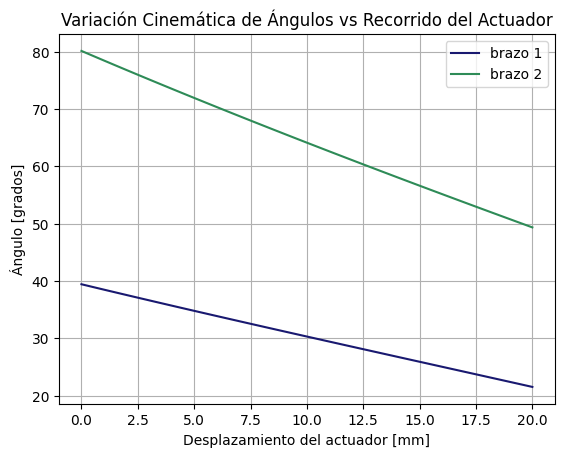

In [71]:
plt.plot(s_val, np.degrees(theta1_sol), label=r'brazo 1', color='midnightblue')
plt.plot(s_val, np.degrees(theta2_sol), label=r'brazo 2', color='seagreen')
plt.xlabel('Desplazamiento del actuador [mm]')
plt.ylabel('Ángulo [grados]')
plt.title('Variación Cinemática de Ángulos vs Recorrido del Actuador')
plt.grid()
plt.legend()
plt.show()

B. Trayectoria en el Espacio de los Puntos

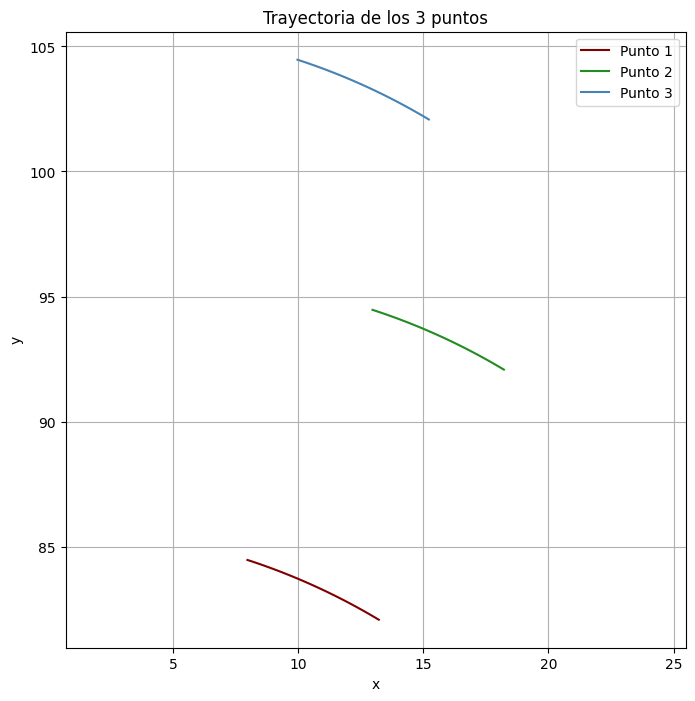

In [72]:
dp1 = sp.symbols('dp1')
gamma = sp.symbols('gamma')
valores_gamma = {gamma:np.deg2rad(25), dp1:60}

vector_origen_b = subida_piston + offset + r1

G = A.orientnew('G', 'Axis', (-theta2 - gamma, A.z))

vector_p1 = (vector_origen_b + dp1 *-G.x).express(N).subs(val).subs(valores_gamma)
display(vector_p1)

f_posicionx_p1 = sp.lambdify((theta,theta2,s),vector_p1.dot(N.x),"numpy")
f_posiciony_p1 = sp.lambdify((theta,theta2,s),vector_p1.dot(N.y),"numpy")


posicionesx_p1, posicionesy_p1 = lista_posiciones_s(theta1_sol,theta2_sol, s_val)


vp1_p2 = [5,10]
vp1_p3 = [2,20]

posicionesx_p2 = [xi + vp1_p2[0] for xi in posicionesx_p1]
posicionesy_p2 = [yi + vp1_p2[1] for yi in posicionesy_p1]
posicionesx_p3 = [xi + vp1_p3[0] for xi in posicionesx_p1]
posicionesy_p3 = [yi + vp1_p3[1] for yi in posicionesy_p1]



graficar_puntos(posicionesx_p1, posicionesy_p1, posicionesx_p2, posicionesy_p2, posicionesx_p3, posicionesy_p3)

C. Posición en Función del Desplazamiento del Actuador Lineal

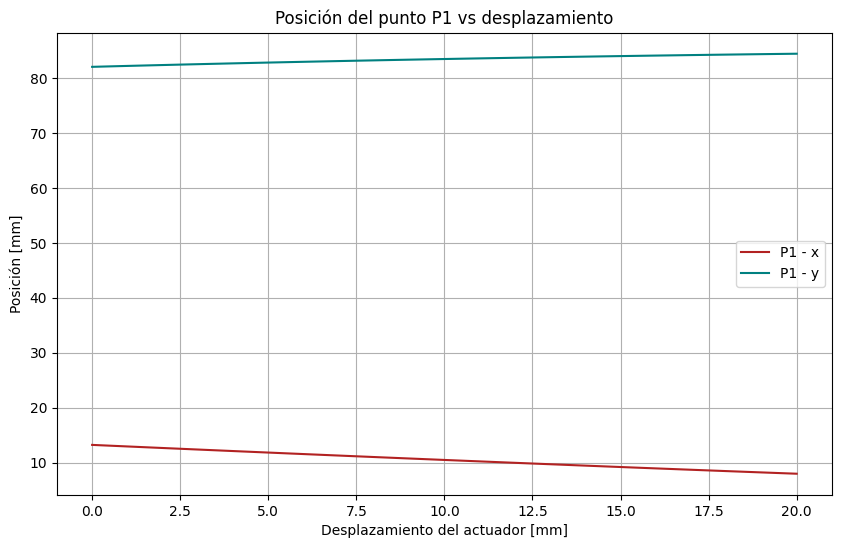

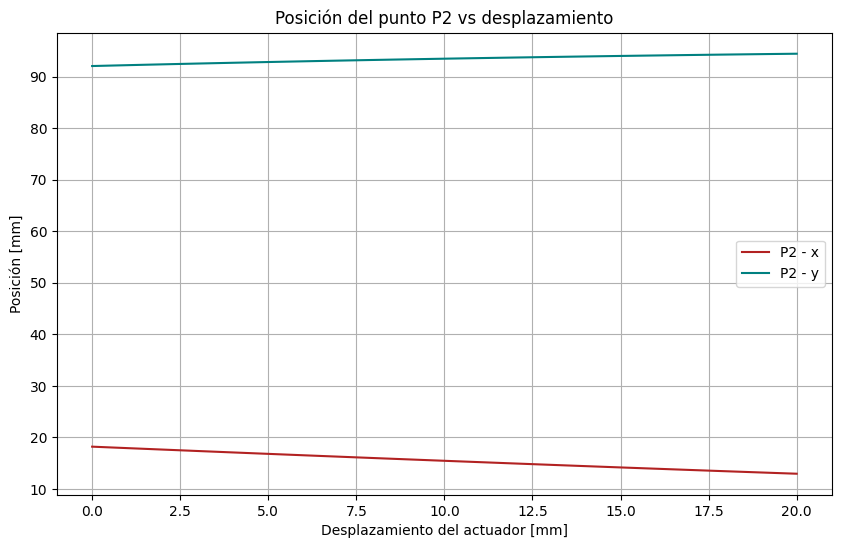

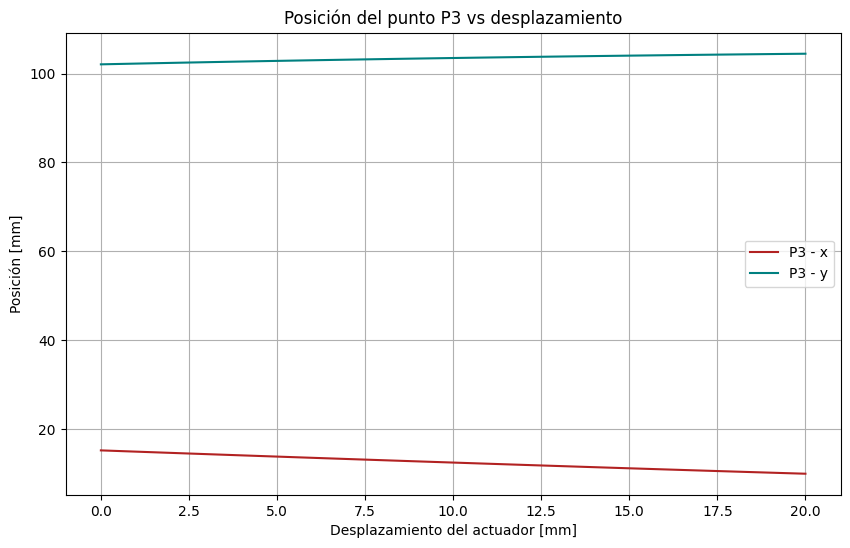

In [73]:
graficar_posiciones_actuador(posicionesx_p1, posicionesy_p1, posicionesx_p2, posicionesy_p2, posicionesx_p3, posicionesy_p3, s_val)

D. Ángulos Respecto al Eje X (En Nuestro Caso Y)

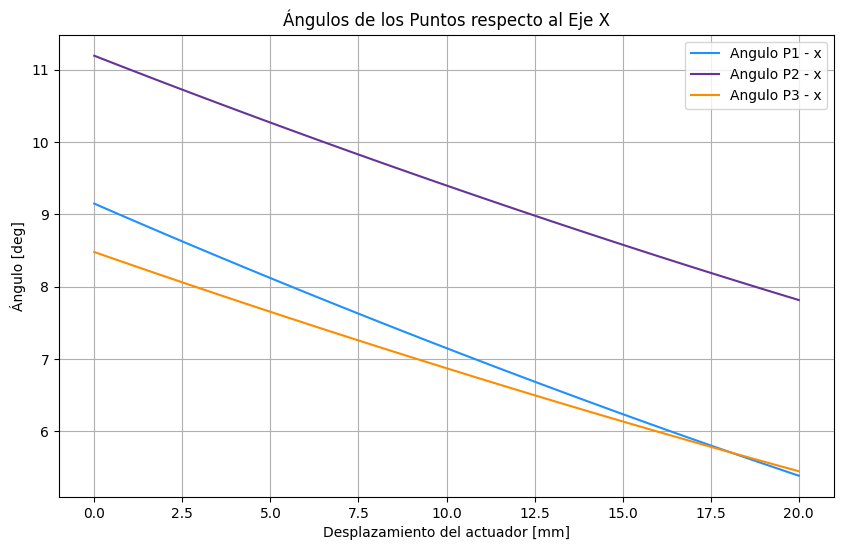

In [75]:
angulos_p1 = angulo_respecto_a_eje(posicionesx_p1, posicionesy_p1)
angulos_p2 = angulo_respecto_a_eje(posicionesx_p2, posicionesy_p2)
angulos_p3 = angulo_respecto_a_eje(posicionesx_p3, posicionesy_p3)
graficar_angulos_actuador(angulos_p1, angulos_p2, angulos_p3, s_val)

E. Datos de Interés para Análisis

In [76]:
# Todos los valores son Respecto al Punto 2 (Promedio)

min_y = min(posicionesy_p2)
max_y = max(posicionesy_p2)
min_x = min(posicionesx_p2)
max_x = max(posicionesx_p2)

print(f" Y Min {min_y}")
print(f" Y Max {max_y}")
print(f" X Min {min_x}")
print(f" X Max {max_x}")

angulo_min_vert = min(angulos_p2)
angulo_max_vert = max(angulos_p2)

print(f" Angulo Min {angulo_min_vert}")
print(f" Angulo Max {angulo_max_vert}")

 Y Min 92.0788228934612
 Y Max 94.46846529989023
 X Min 12.965392874690146
 X Max 18.216612933061082
 Angulo Min 7.81477738698464
 Angulo Max 11.19072774603552


# Punto 3

Aclaración: La razón de los valores negativos asociados a las posiciones corresponden a la elección de los marcos de referencia establecidos en el esquemático. Posteriormente para el análisis se tendrá en cuenta este cambio y se realizarán las adaptaciones correspondientes para la comparación.

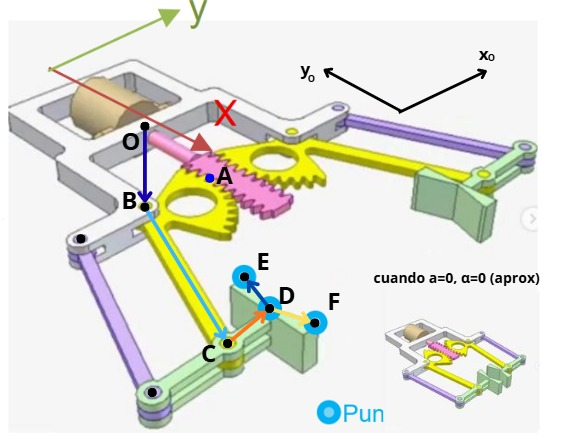

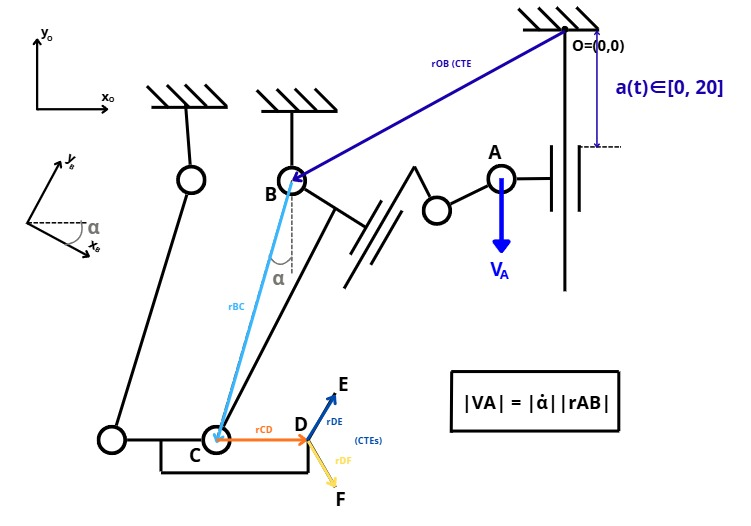

In [110]:
import numpy as np
import sympy
from sympy import symbols
from sympy.physics.mechanics import ReferenceFrame, dynamicsymbols, init_vprinting

init_vprinting()

#A es un punto primitivo. Este no se desplaza respecto al marco de referencia O.
#Nota: Se usa el marco de referencia O, no el propuesto por el diagrama (excepto para el ángulo ya que lo piden respecto a este X)

a, alpha = dynamicsymbols("a, alpha")
t, r_OBx, r_OBy, l_BC, r_CDx, r_DEx, r_DEy = symbols("t, r_OBx, r_OBy, l_BC, r_CDx, r_DEx, r_DEy")

params = {r_OBx: 25, r_OBy: 30, l_BC: 60, r_CDx: 15, r_DEx: 3, r_DEy: 10}#[mm] a ojo

O=ReferenceFrame("O")
B=O.orientnew("B", "Axis", (-alpha, O.z))

vA=-a.diff(t)*O.y

rOB = -r_OBx*O.x -r_OBy*O.y
rBC = -B.y*l_BC
rCD = r_CDx*O.x
rDE = r_DEx*O.x + r_DEy*O.y
rDF = r_DEx*O.x - r_DEy*O.y

rOD=rOB+rBC+rCD
rOD=rOD.express(O)
display(rOD)

# 5. Relaciones angulares
#alpha=integral(alpha_dot, t) con alpha(0)=0, alpha CTE en intervalo, luego alpha(t)=alpha_dot*t
rOD=rOD.subs({alpha: alpha.diff(t)*t})

#Escalarmente, vA=alpha_dot*r_ABx; alpha_dot = vA/r_ABx

vA_norm = sympy.sqrt(vA.dot(O.y)**2)
alpha_dot_norm=vA_norm/r_OBx
display(rOD)

rOD=rOD.subs({alpha.diff(t): alpha_dot_norm})


#Tenemos posición en función de a y su cambio. suponemos que a aumenta linealmente de 0 a 20 en un segundo. Luego a(t) = a't con a' = 20 mm/s 
rOD=rOD.subs({a: a.diff(t)*t})
rOE=rOD+rDE
rOF=rOD+rDF

# 6. Substituciones numéricas

movimiento_a = {a.diff(t, 2): 0, a.diff(t): 20}
rOD=rOD.subs(params).subs(movimiento_a).simplify()
rOE=rOE.subs(params).subs(movimiento_a).simplify()
rOF=rOF.subs(params).subs(movimiento_a).simplify()

# 7. Lambdificación y busqueda de puntos de interés

rODx_fun = sympy.lambdify(t, rOD.dot(O.x), "numpy")
rODy_fun = sympy.lambdify(t, rOD.dot(O.y), "numpy")
rOEx_fun = sympy.lambdify(t, rOE.dot(O.x), "numpy")
rOEy_fun = sympy.lambdify(t, rOE.dot(O.y), "numpy")
rOFx_fun = sympy.lambdify(t, rOF.dot(O.x), "numpy")
rOFy_fun = sympy.lambdify(t, rOF.dot(O.y), "numpy")



B. Trayectoria en el Espacio de los Puntos

B)


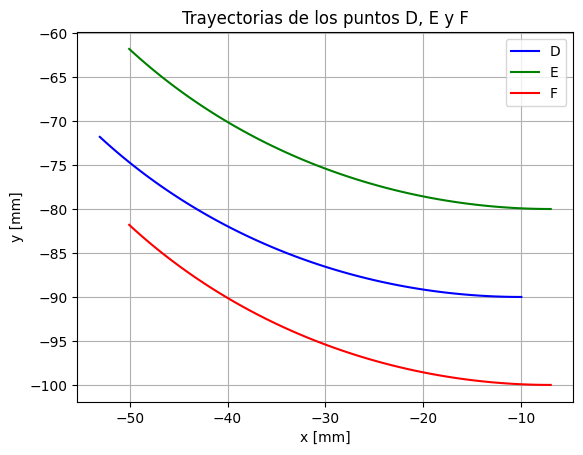

In [111]:
import matplotlib.pyplot as plt
t_linspace = np.linspace(0, 1, 100)
plt.plot(rODx_fun(t_linspace), rODy_fun(t_linspace), label="D", color="blue")
plt.plot(rOEx_fun(t_linspace), rOEy_fun(t_linspace), label="E", color="green")
plt.plot(rOFx_fun(t_linspace), rOFy_fun(t_linspace), label="F", color="red")

plt.xlabel("x [mm]")
plt.ylabel("y [mm]")
plt.title("Trayectorias de los puntos D, E y F")
plt.legend()
plt.grid(True)

print("B)")
plt.show()

In [112]:
# Todos los valores son Respecto al Punto 2 (En este caso el Punto E) (Promedio)

min_y = min(rOEy_fun(t_linspace))
max_y = max(rOEy_fun(t_linspace))
min_x = min(rOEx_fun(t_linspace))
max_x = max(rOEx_fun(t_linspace))

print(f" Y Min {min_y}")
print(f" Y Max {max_y}")
print(f" X Min {min_x}")
print(f" X Max {max_x}")

 Y Min -80.0
 Y Max -61.802402560829925
 X Min -50.041365453971366
 X Max -7.0


C. Posición en Función del Desplazamiento del Actuador Lineal

C)


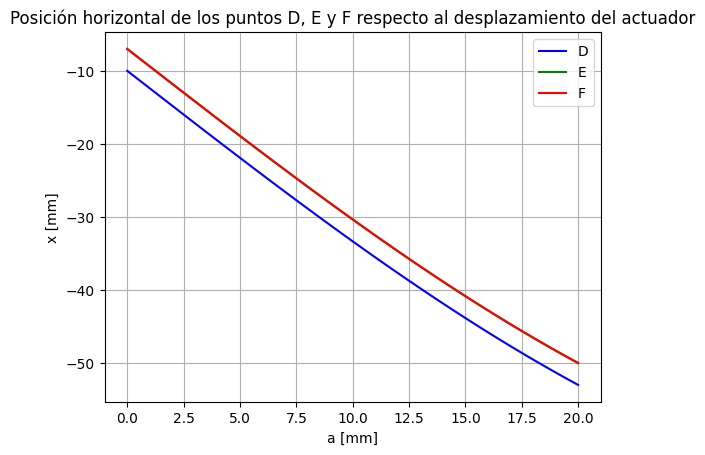

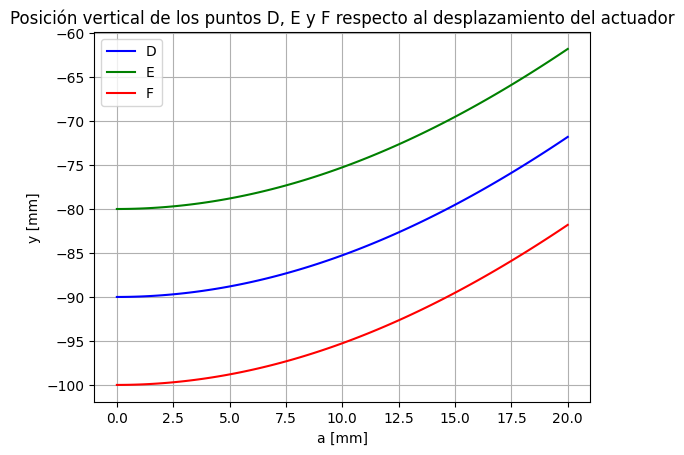

In [113]:
#C: x vs a, y vs a. Simplemente hacemos la sustitución t=a/a'
print("C)")
rOD=rOD.subs({t: a/20})
rOE=rOE.subs({t: a/20})
rOF=rOF.subs({t: a/20})
rODx_fun = sympy.lambdify(a, rOD.dot(O.x), "numpy")
rODy_fun = sympy.lambdify(a, rOD.dot(O.y), "numpy")
rOEx_fun = sympy.lambdify(a, rOE.dot(O.x), "numpy")
rOEy_fun = sympy.lambdify(a, rOE.dot(O.y), "numpy")
rOFx_fun = sympy.lambdify(a, rOF.dot(O.x), "numpy")
rOFy_fun = sympy.lambdify(a, rOF.dot(O.y), "numpy")
a_linspace = np.linspace(0, 20, 100)

plt.plot(a_linspace, rODx_fun(a_linspace), label="D", color="blue")
plt.plot(a_linspace, rOEx_fun(a_linspace), label="E", color="green")
plt.plot(a_linspace, rOFx_fun(a_linspace), label="F", color="red")
plt.xlabel("a [mm]")
plt.ylabel("x [mm]")
plt.title("Posición horizontal de los puntos D, E y F respecto al desplazamiento del actuador")
plt.legend()
plt.grid(True)
plt.show()


plt.plot(a_linspace, rODy_fun(a_linspace), label="D", color="blue")
plt.plot(a_linspace, rOEy_fun(a_linspace), label="E", color="green")
plt.plot(a_linspace, rOFy_fun(a_linspace), label="F", color="red")
plt.xlabel("a [mm]")
plt.ylabel("y [mm]")
plt.title("Posición vertical de los puntos D, E y F respecto al desplazamiento del actuador")
plt.legend()
plt.grid(True)
plt.show()

D. Ángulos Respecto al Eje Axial

D)


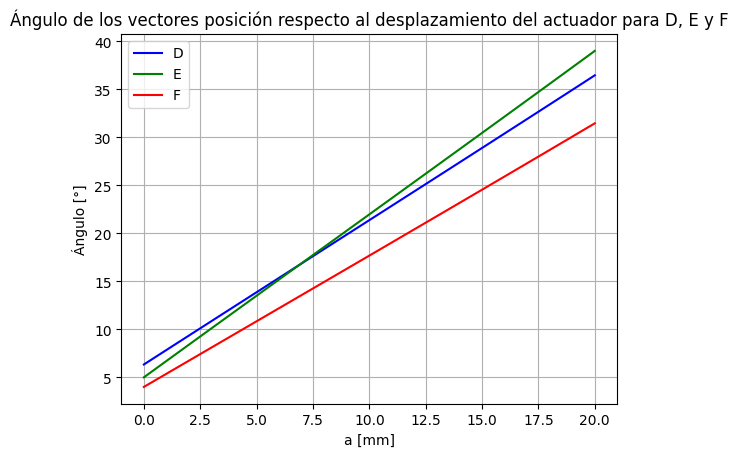

In [114]:
#Ángulo entre eje x y vectores posición en función de a. Como ambas componentes son negativas, el ángulo estará en el tercer cuadrante, por lo que se puede usar arctan(x/y) para obtenerlo.

plt.plot(a_linspace, np.arctan(rODx_fun(a_linspace)/rODy_fun(a_linspace)) * 180 / np.pi, label="D", color="blue")
plt.plot(a_linspace, np.arctan(rOEx_fun(a_linspace)/rOEy_fun(a_linspace)) * 180 / np.pi, label="E", color="green")
plt.plot(a_linspace, np.arctan(rOFx_fun(a_linspace)/rOFy_fun(a_linspace)) * 180 / np.pi, label="F", color="red")

plt.xlabel("a [mm]")
plt.ylabel("Ángulo [°]")
plt.title("Ángulo de los vectores posición respecto al desplazamiento del actuador para D, E y F")
plt.legend()
plt.grid(True)

print("D)")
plt.show()
plt.show()

E. Datos de Interés para Análisis

In [115]:
angulo_min_vert = min(np.arctan(rOEx_fun(a_linspace)/rOEy_fun(a_linspace)) * 180 / np.pi)
angulo_max_vert = max(np.arctan(rOEx_fun(a_linspace)/rOEy_fun(a_linspace)) * 180 / np.pi)

print(f" Angulo Min {angulo_min_vert}")
print(f" Angulo Max {angulo_max_vert}")

 Angulo Min 5.000644597558433
 Angulo Max 38.9970696434347


# PARTE 2 - DISCUSIÓN

### Análisis y Discusión de Resultados

Para comparar el funcionamiento de los mecanismos, se utilizaron las gráficas obtenidas a partir del movimiento del punto de interés intermedio de cada uno. Con el fin de garantizar una comparación consistente, los resultados fueron representados bajo un mismo sistema de referencia y teniendo en cuenta la escala de cada modelo.

Descripción cualitativa del movimiento por mecanismo

Mecanismo 1:
El mecanismo recibe como entrada el desplazamiento lineal del actuador, ubicado en la parte central del conjunto y conectado a los brazos del mecanismo. Cada brazo está conformado por una cadena de dos cuerpos de longitud constante. El primer cuerpo está unido al marco mediante una junta de revoluta, mientras que los dos cuerpos se encuentran conectados entre sí mediante otra junta de revoluta. El segundo cuerpo se conecta al actuador, permitiendo que su desplazamiento genere el movimiento rotacional de los brazos.

De esta manera, la extensión del actuador produce la apertura del sistema de agarre, mientras que su compresión genera el cierre del mismo.

Mecanismo 2:
El segundo mecanismo recibe también como entrada el desplazamiento lineal, ubicado en el centro del mecanismo. En este mecanismo, los brazos también están compuestos de una cadena de dos cuerpos de longitud constante, pero sus uniones cambian con respecto al sistema. Los primeros conectan directamente al actuados con juntas de revoluta, y están conectados entre ellos también con una junta de revoluta. Los brazos conectan en sus extremos con revolutas al marco del mecanismo, eje sobre el cual se da la rotación de las garras.

En este sistema, al contrario del primer mecanismo, la extensión del actuador produce el cierre del sistema de agarre.

Adicionalmente, en este mecanismo se debe considerar que la forma de las mordazas son curvadas, lo cual es mejor para agarrar objetos curvos pero limita su efectividad para agarrar objetos pequeños cuando las mordazas se cierran por completo.

Mecanismo 3:
El tercer mecanismo también tiene una entrada en el deslizamiento de un actuador, pero que en este caso corresponde a una corredera que transfiere el movimiento por medio de la conexión a un cuerpo combinado entre barra y engranaje. En este sistema, los brazos están conformados por una cadena de tres cuerpos de dimensiones fijas, donde el primer cuerpo es la barra-engranaje que transmite la rotación sobre sus juntas de revoluta al marco, el segundo es una barra conectada con una revoluta al marco y el tercero es una barra adicional que conecta el movimiento de las dos anteriores.

Para este mecanismo, al igual que en el primero la extensión del actuador produce la apertura del sistema de agarre, y la compresión cierra el mecanismo

### Comparación cuantitativa del movimiento por mecanismo

In [116]:
import pandas as pd

df = pd.DataFrame({"Criterio": ["Rango de alcance en x [mm]", "Rango de alcance en y [mm]", "Rango de alcance angular [°]"],
    "Mecanismo 1": [[41.59, 49.03],[75.93, 86.66],[28.35, 29.49]],
    "Mecanismo 2": [[12.96, 18.22],[92.07, 94.47],[7.81, 11.19]],
    "Mecanismo 3": [[7, 50.1],[61.8, 80],[5, 38]]})

df

,Criterio,Mecanismo 1,Mecanismo 2,Mecanismo 3
0,Rango de alcance en x [mm],"[41.59, 49.03]","[12.96, 18.22]","[7, 50.1]"
1,Rango de alcance en y [mm],"[75.93, 86.66]","[92.07, 94.47]","[61.8, 80]"
2,Rango de alcance angular [°],"[28.35, 29.49]","[7.81, 11.19]","[5, 38]"


Los resultados muestran diferencias significativas en el alcance de las trayectorias generadas por los tres mecanismos. El Mecanismo 1 presenta un movimiento relativamente restringido en las direcciones X y Y, con variaciones de 7.44 mm y 10.73 mm, respectivamente. Además, su rango angular es reducido, con una variación de aproximadamente 1.14°, lo que indica que el punto de interés mantiene una trayectoria con poca variación de orientación.

El Mecanismo 2 presenta el menor desplazamiento en ambas direcciones, con variaciones de 5.26 mm en X y 2.40 mm en Y. Su rango angular es de aproximadamente 3.38°. Por lo tanto, el movimiento del punto de interés se encuentra más restringido, aunque presenta una variación angular ligeramente superior a la del Mecanismo 1.

Por otro lado, el Mecanismo 3 presenta una trayectoria considerablemente más amplia, con variaciones de 43.10 mm en X y 18.20 mm en Y, además de un rango angular de 33°. Esto representa una mayor capacidad de desplazamiento y cambio de orientación del punto de interés frente a los otros dos mecanismos.

En términos comparativos, el Mecanismo 2 genera el movimiento más reducido y concentrado, mientras que el Mecanismo 3 permite el mayor rango de movimiento. El Mecanismo 1 presenta un comportamiento intermedio en cuanto a desplazamiento, pero con una variación angular particularmente pequeña.


### Determinación Final de Mecanismo

Para la determinación del mejor mecanismo, se consideraron los siguientes criterios de evaluación, los cuales coinciden con la información analizada anteriormente de cada uno:
- Rango del mecanismo: corresponde al intervalo de movimiento que puede alcanzar un punto de interés de salida del mecanismo, considerando las posiciones límite que puede adoptar durante su operación.
- Espacio ocupado: corresponde al espacio físico requerido por el mecanismo para realizar su movimiento, considerando tanto sus dimensiones como las trayectorias descritas por los brazos durante su funcionamiento.
- Complejidad: corresponde al nivel de dificultad asociado con la construcción física del mecanismo, considerando principalmente el número de brazos y componentes requeridos.

In [3]:
import pandas as pd

df_comparacion = pd.DataFrame({ "Mecanismo": ["Mecanismo 1", "Mecanismo 2", "Mecanismo 3"], "Rango": ["Intermedio", "Bajo", "Alto"],
    "Espacio ocupado": ["Intermedio", "Menor", "Mayor"], "Complejidad": ["Intermedia", "Intermedia", "Mayor"],
    "Versatilidad de agarre": ["Alta", "Limitada", "Alta"], "Variación angular": ["Muy baja", "Baja", "Alta"]})

df_comparacion

,Mecanismo,Rango,Espacio ocupado,Complejidad,Versatilidad de agarre,Variación angular
0,Mecanismo 1,Intermedio,Intermedio,Intermedia,Alta,Muy baja
1,Mecanismo 2,Bajo,Menor,Intermedia,Limitada,Baja
2,Mecanismo 3,Alto,Mayor,Mayor,Alta,Alta


En consideración de los criterios anteriores, se determinó que la selección del mecanismo depende principalmente de la prioridad establecida para la aplicación. Si el objetivo es maximizar la capacidad de operación, el Mecanismo 3 resulta la alternativa más conveniente, ya que presenta el mayor rango de movimiento tanto lineal como angular, permitiendo una mayor área de operación y una mayor capacidad de adaptación durante el agarre. Esta ventaja, sin embargo, implica una mayor complejidad y un mayor espacio de operación.

Por otro lado, si se busca una solución intermedia entre capacidad de operación, espacio ocupado y complejidad, el Mecanismo 2 representa una alternativa equilibrada. Su rango de movimiento es menor, pero su configuración permite un movimiento más restringido y un sistema relativamente compacto. Adicionalmente, la geometría curva de sus mordazas puede favorecer el agarre de objetos de determinadas formas, aunque limita su desempeño con objetos pequeños.